# Понижение размерности

In [8]:
!pip install requests numpy pandas matplotlib scikit-learn seaborn

# ЗАДАНИЕ 1

**1. Иероглифы.** Чтобы немного соригинальничать, воспользуемся не МНИСТом, а его аналогом с иероглифами. Скачайте обрезанную версию с 10 классами
https://github.com/rois-codh/kmnist

Изобразите по несколько представителей каждого класса, предположите, какие из них будет сложнее различить.

Скачиваю kmnist-train-imgs.npz...
Скачиваю kmnist-train-labels.npz...
Скачиваю kmnist-test-imgs.npz...
Скачиваю kmnist-test-labels.npz...
Размер обучающей выборки: (60000, 28, 28)


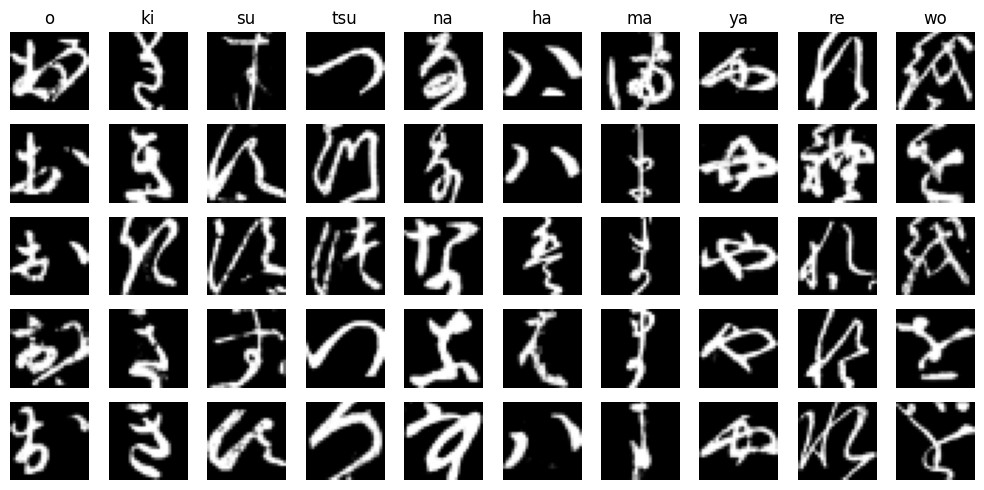

In [4]:
import numpy as np  # Библиотека для работы с массивами и матрицами 
import matplotlib.pyplot as plt  # Библиотека для рисования графиков и картинок
import requests  # Библиотека для скачивания файлов из интернета
import os  # Библиотека для работы с файловой системой (проверка наличия файлов)

# Функция для скачивания файлов, если их нет на диске
def download_kmnist():
    # Базовая ссылка на репозиторий, где лежат файлы
    base_url = "http://codh.rois.ac.jp/kmnist/dataset/kmnist/"
    # Список файлов, которые нам нужны (обучение и тест, картинки и метки)
    files = [
        'kmnist-train-imgs.npz',
        'kmnist-train-labels.npz',
        'kmnist-test-imgs.npz',
        'kmnist-test-labels.npz'
    ]
    
    # Проходимся по каждому имени файла в списке
    for file in files:
        # Если файла нет в текущей папке
        if not os.path.exists(file):
            print(f"Скачиваю {file}...")  # Сообщаем пользователю
            # Скачиваем файл по ссылке
            response = requests.get(base_url + file)
            # Открываем файл на запись в бинарном режиме ('wb') и сохраняем контент
            with open(file, 'wb') as f:
                f.write(response.content)
        else:
            print(f"Файл {file} уже существует.") # Если уже скачали ранее

# Функция для загрузки данных из .npz архива
def load(f):
    # np.load открывает архив. ['arr_0'] — это ключ, под которым там лежит массив по умолчанию
    return np.load(f)['arr_0']

# --- ВЫПОЛНЕНИЕ ---

# 1. Скачиваем данные
download_kmnist()

# 2. Загружаем данные в переменные
# x_train: картинки для обучения
x_train = load('kmnist-train-imgs.npz')
# x_test: картинки для проверки (теста)
x_test = load('kmnist-test-imgs.npz')
# y_train: правильные ответы для обучения (цифры 0-9)
y_train = load('kmnist-train-labels.npz')
# y_test: правильные ответы для теста
y_test = load('kmnist-test-labels.npz')

# Выведем размерность, чтобы убедиться, что все ок
# Должно быть (60000, 28, 28) — 60 тысяч картинок 28x28
print(f"Размер обучающей выборки: {x_train.shape}")

# 3. Визуализация (Рисуем по несколько представителей каждого класса)
# Список японских названий символов (просто для красоты, чтобы знать, что это)
labels_char = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Создаем "канвас" (фигуру) размером 10 на 5 дюймов
plt.figure(figsize=(10, 5))

# Цикл от 0 до 9 (по всем классам)
for i in range(10):
    # Находим индексы всех картинок, где метка равна i (например, все картинки с символом 'o')
    indices = np.where(y_train == i)[0]
    
    # Берем первые 5 картинок этого класса
    for j in range(5):
        # Добавляем под-график (subplot). 
        # 5 строк, 10 столбцов. Позиция рассчитывается хитрой формулой.
        plt.subplot(5, 10, j * 10 + i + 1)
        
        # Рисуем картинку. indices[j] — это номер картинки в общем массиве.
        # cmap='gray' делает картинку черно-белой.
        plt.imshow(x_train[indices[j]], cmap='gray')
        
        # Убираем оси координат (цифры по бокам), чтобы было красиво
        plt.axis('off')
        
        # Если это первая строка, подпишем сверху название класса (на японском/английском)
        if j == 0:
            plt.title(labels_char[i])

# Показываем все, что нарисовали
plt.tight_layout()
plt.show()

я скачал данне и изобразил примеры иероглифов на графике/картинке/таблице (?)
#  предположите, какие из них будет сложнее различить.
- re может иметь много общего с tsu и некоторыми su. даже есть пример очень похожей ki
- некоторые виды ha могут иметь много общего с ma, некоторыми ki
- o может где-то отдаленно напоминать ya
- wo и ya где-то похожи на А


# ЗАДАНИЕ 2

**2. Бэйзлайн.** В качестве бэйзлайна обучите на сырых данных:
   - KNN
   - Случайный лес
   - Давайте LDA еще сюда добавим.
  
     Переберите гиперпараметры, для выбранных моделей постройте confusion матрицы, выведите `accuracy_score`. По матрицам определите 3 пары иероглифов, которые алгоритм путает чаще всего. Нарисуйте несколько ошибочно классифицированных представителей этих классов.

     Объясните, почему LDA так плох.

Размерность до: (60000, 28, 28)
Размерность после: (60000, 784)

--- Работаем с KNN ---
Обучаюсь...
Предсказываю...
Точность (Accuracy): 0.9143


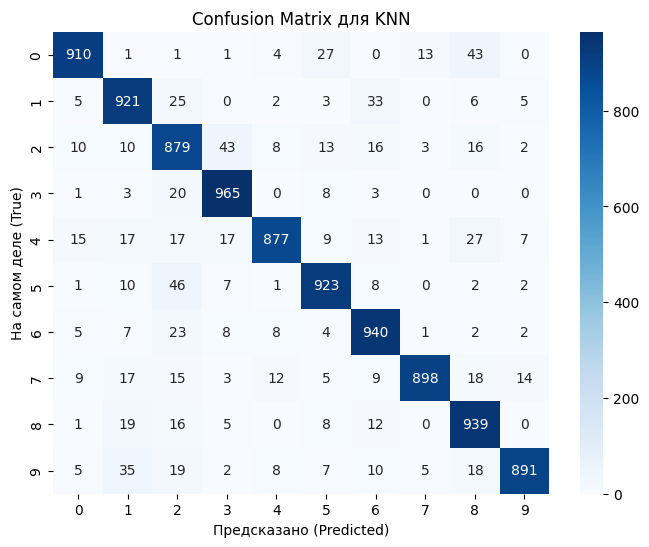

Всего ошибок: 857


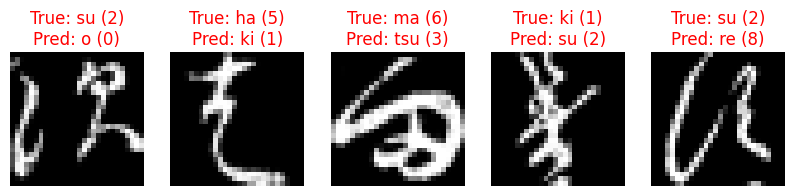


--- Работаем с Random Forest ---
Обучаюсь...
Предсказываю...
Точность (Accuracy): 0.8556


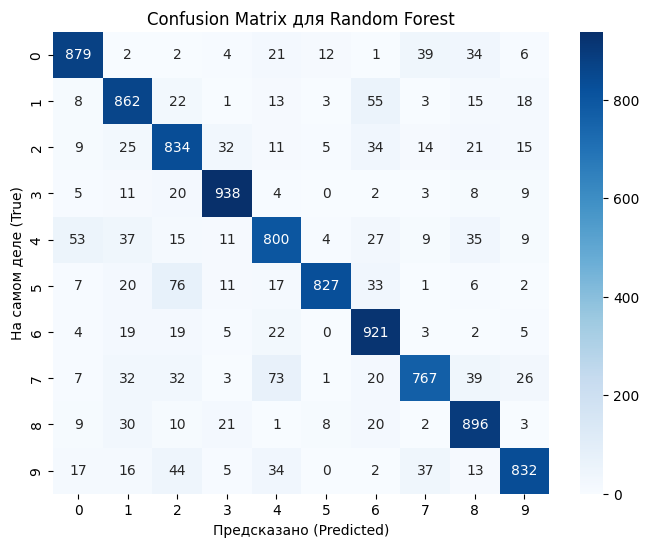

Всего ошибок: 1444


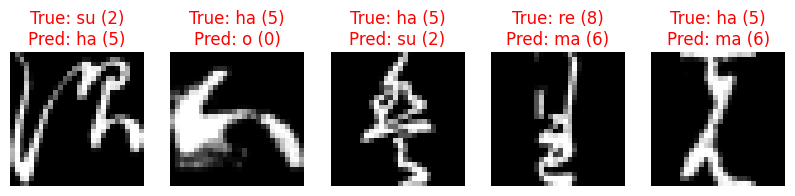


--- Работаем с LDA ---
Обучаюсь...
Предсказываю...
Точность (Accuracy): 0.5890


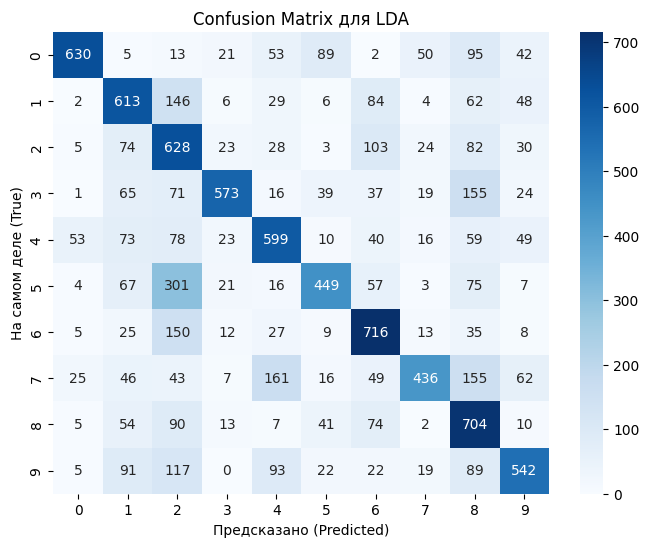

Всего ошибок: 4110


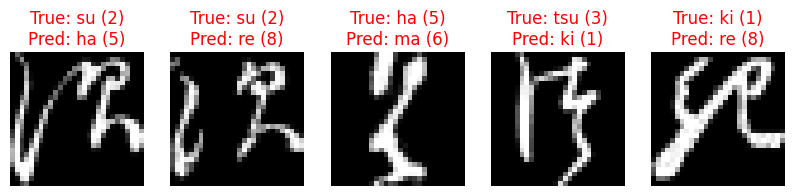

In [16]:
# --- ИМПОРТЫ ---
# Импортируем сами алгоритмы (модели)
from sklearn.neighbors import KNeighborsClassifier  # KNN
from sklearn.ensemble import RandomForestClassifier # Случайный лес
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # LDA

# Импортируем инструменты для оценки качества
from sklearn.metrics import accuracy_score, confusion_matrix # Точность и Матрица ошибок
import seaborn as sns # Библиотека для красивого рисования матриц (тепловые карты)

# --- ПОДГОТОВКА ДАННЫХ ---

# Напоминание: модели хотят вектор (строку), а у нас матрицы (28x28).
# Функция reshape(-1, 784) делает следующее:
# -1 говорит: "посчитай количество строк сам" (оставь 60000)
# 784 говорит: "сделай так, чтобы в каждой строке было 784 числа"
x_train_flat = x_train.reshape(-1, 784) 
x_test_flat = x_test.reshape(-1, 784)

print(f"Размерность до: {x_train.shape}")      # (60000, 28, 28)
print(f"Размерность после: {x_train_flat.shape}") # (60000, 784)

# Создаем список моделей, чтобы запустить их в цикле (не писать код 3 раза)
# Словарик: "Название модели" -> Сам объект модели
models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Random Forest": RandomForestClassifier(n_estimators=75, random_state=42),
    "LDA": LinearDiscriminantAnalysis()
}

# --- ОБУЧЕНИЕ И ПРОВЕРКА ---

for name, model in models.items():
    print(f"\n--- Работаем с {name} ---")
    
    # 1. Обучение (fit)
    # Мы скармливаем модели "плоские" картинки и правильные ответы
    print("Обучаюсь...")
    model.fit(x_train_flat, y_train)
    
    # 2. Предсказание (predict)
    # Просим модель угадать классы для тестовых картинок
    print("Предсказываю...")
    y_pred = model.predict(x_test_flat)
    
    # 3. Оценка точности (accuracy)
    # Сравниваем угаданное (y_pred) с правильным (y_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Точность (Accuracy): {acc:.4f}") # Выводим 4 знака после запятой
    
    # 4. Матрица ошибок (Confusion Matrix)
    # Показывает: сколько раз класс 0 был назван классом 5 и т.д.
    cm = confusion_matrix(y_test, y_pred)
    
    # Рисуем матрицу красиво
    plt.figure(figsize=(8, 6))
    # sns.heatmap - тепловая карта. annot=True пишет цифры в ячейках. fmt='d' - целые числа.
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix для {name}")
    plt.ylabel('На самом деле (True)')
    plt.xlabel('Предсказано (Predicted)')
    plt.show()

    labels_char = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']
    # В задании просят: "Нарисуйте несколько ошибочно классифицированных"
    # Сделаем это для текущей модели
    # Находим индексы, где предсказание НЕ совпало с реальностью
    # y_pred != y_test возвращает True/False. np.where превращает это в номера индексов.
    errors_indices = np.where(y_pred != y_test)[0]
    
    print(f"Всего ошибок: {len(errors_indices)}")
    
    # Нарисуем первые 5 ошибок
    if len(errors_indices) > 0:
        plt.figure(figsize=(10, 2))
        for i in range(5):
            idx = errors_indices[i] # Берем номер ошибочной картинки
            
            # Получаем цифры
            true_idx = y_test[idx]
            pred_idx = y_pred[idx]
            
            # Получаем имена по цифрам
            true_name = labels_char[true_idx]
            pred_name = labels_char[pred_idx]
            
            plt.subplot(1, 5, i + 1)
            # Рисуем саму картинку (берем из оригинального x_test, который 28x28)
            plt.imshow(x_test[idx], cmap='gray')
            plt.axis('off')
            # Пишем: "Был класс X, робот сказал Y"
            plt.title(f"True: {true_name} ({true_idx})\nPred: {pred_name} ({pred_idx})", color='red', fontsize=12)
        plt.show()

# о деревьях
у нас n деревьев , где 784 потенциальных темы на вопросы (сколько пикселей). 

количество вопросов может определить тем, насколько пикель(x,y) помогает оценить иероглиф: 
- если с этим пикселем у меня куча классов может быть -- мимо
- если с этим пикселем явно выделяется подкласс пикселей -- круто

и вот так мы получаем группку, и потом мы эту группку делим. качество вопросов определяется по такому же принципу

задача обучения дерева -- подобрать такие вопросы, чтобы определять тренировочные данные
чтобы у нас было "мнение толпы", мы делаем n деревьев. тренируется каждое дерево на n данных, но для каждого перемешиваем по особенному-случайному
после обучения каждое сформировало свое мнение
и когда мы даем некий набор, то он проходит черед все деревья и в результате мы собираем общее мнение толпы

# Переберите гиперпараметры, для выбранных моделей постройте confusion матрицы, выведите `accuracy_score`
я перебрал немного параметров и выявил что
- чем больше деревьев, тем лучше accuracy. но -- я увеличивал количество деревьев чуть ли не в 2 раза, а результат мог быть до 1 процента. поэтому я решил остановиться на "оптимальном" значении 75
- количество соседей для KNN: самый лучший accuracy на n=1. в нашем случае это вероятно неплохой вариант, так как у нас много данных и мало шума

касаемо самих результатов -- все приведены в выводе. \
- KNN: Точность (Accuracy): 0.9143
- Случайный лес: Точность (Accuracy): 0.8556
- LDA: Точность (Accuracy): 0.5890

# По матрицам определите 3 пары иероглифов, которые алгоритм путает чаще всего. Нарисуйте несколько ошибочно классифицированных представителей этих классов.
все есть в выводе

# Объясните, почему LDA так плох.
LDA -- это линейный класификатор. он хочет провести линию(гиперплоскост), которая будет отделять классы в 28*28 пространстве. что не очень то и возможно, так как мы еще в самом начале убедились, что -- символы могут повторяться. и вероятно это и есть нелинейная зависимость

# Почему KNN показал себя лучше, чем Случайный лес?
KNN сравнивает картинку целиком, а Лес задает вопросы конкретным пикселям.

# ЗАДАНИЕ 3

**3. Метод главных компонент.** Обучите sklearn-овский PCA. Не забудьте про масштабирование. К сожалению там уже максимально облегчили вам задачу по выбору числа компонент, но мы все равно порисуем картинки.
   - картинка 1: по оси х - число учтенных компонент, по оси у - процент дисперсии, за который они отвечают. Будьте готовы объяснить, как вычисляется этот процент дисперсии, хоть sklearn и вычислил его за вас
   - картинка 2: скэттер-плот на 2 (или 3, если вы в смелом настроении!) главные компоненты, так, чтоб было понятно, какая точка к какому классу относится. Плотить можно какое-то меньшее подмножество, просто смотрите, чтоб в нем хотя бы все классы были одинаково представлены
  
Обучите снова те же алгоритмы (возможно, с другими гиперпараметрами), сравните результаты.

Что вообще делает PCA? Почему важно стандаризировать данные? 

*Есть стандартная рекомендация о том, чтобы выбирать столько компонент, которые объясняют 95% дисперсии. Рекомендуется поэкспериментировать с выбором куда меньшего их числа. Альтернативная рекомендация - поиск "локтя" на картинке 1, но здесь он не очень острый*

**4. UMAP.** Первые две главные компоненты вряд ли позволили получить какой-то вразумительный график. Попытаем счастья с UMAP-ом. Его придется установить отдельно (https://umap-learn.readthedocs.io/en/latest/basic_usage.html). Поскольку это нужно нам только для визуализации, обучить его можете на тестовых данных, а может и на каком-то их подмножестве - потому что памяти, вероятно, будет не хватать... (это та часть лабы, которую я сама делать не пробовала)

**5. Kernel PCA.** Хотелось бы попробовать ядерный PCA на тех же данных, но тут опять можно столкнуться с нехваткой памяти (объясните, почему с обычным РСА такой проблемы не было). Однако поиграться с ядрами все-таки хочется, так что сделаем это хотя бы на синтетических датасетах. Признаков у нас тут и так немного, однако границы между классами / зависимость получаются совсем не линейные - хотя на глаз и вполне понятные. Конечно, KNN с этим бы справился без проблем, но мы тут хотим просто проследить, что разные ядра способны улавливать и распрямлять. Для каждого датасета из файла:

- изобразите его исходную версию. Раскрасьте в соответствии со значением целевой переменной (она всегда в последнем столбце)
- примените каждое из доступных в `KernelPCA` ядер (в некоторых можно попробовать разные значения параметров), получите главные компоненты
- примените какое-нибудь недоступное в `KernelPCA` ядро (подайте в качестве аргумента callable. Примеры неупомянутых в sklearn, но стандартных ядер: exponential, laplacian; ну и, вдохновившись обобщенным RBF ядром вы можете придумать совершенно уникальное ядро имени вас любимых)
- для каждого использованного ядра изобразите данные в пространстве выделенных главных компонент (3D - или 2D, если в нем тоже красиво)

*Для некоторых датасетов может и не выйдет ничего хорошего, это нормально. Данные, опять же, рекомендуется стандартизировать.*

In [ ]:
xl = pd.ExcelFile('pcadata.xlsx')
xl.sheet_names

In [ ]:
data = xl.parse('Concentric', header=None, names=['x1','x2','x3','y'])
data.head()

**6. LLE.** Тем, у кого не получилось красивой картинки с `KernelPCA`, еще может помочь LLE. Поперебирайте его параметры, и для каждого датасета изобразите результат, который показался вам наиболее удачным. Какие, на ваш взгляд, есть достоинства и недостатоки у LLE по сравнению с PCA?

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding